In [2]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import matplotlib.style

matplotlib.style.use("ggplot")

In [4]:
import nltk

nltk.download(["punkt"])

[nltk_data] Downloading package punkt to /home/fahmi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Corpus

In [5]:
df_corpus = pd.read_json(f"../data/corpus.jsonl", lines=True)
print(df_corpus.shape)

df_corpus.head()

(1499, 6)


,id,title,content,published_at,word_count,source_url
0,0f438470-de7f-47cb-8ba2-16e8b1ff5750,JEMBAR SABAR,bismillah yuga lampah balukar janglar meunang ...,2023-07-24,66,https://basasunda.com/puisi-bahasa-sunda
1,c51ddd60-adc7-4b95-b09d-3c4865ba2aaf,KANYERI,eweuh deui seri nu lewih nyeri tibatan di héna...,2023-07-24,94,https://basasunda.com/puisi-bahasa-sunda
2,cb4eb9c6-bf7f-4edc-b997-73a02780e60d,KARUNGING LAIN WAYAH,wanci gayuh ka peuting poék tungkeb haté lain ...,2023-07-24,50,https://basasunda.com/puisi-bahasa-sunda
3,af9fc2c2-0230-4784-8104-cf9271ccfccc,KUDU DAÉK GAWÉ,ieu awak asa lalungsé di rasa asa carapé meure...,2023-07-24,53,https://basasunda.com/puisi-bahasa-sunda
4,2ae6c860-37c6-47f0-aefc-8b74f96b623b,PUISI PANGGGEUING DIRI,naha anjeun téh poho yén mot téh dodoho datang...,2023-07-24,77,https://basasunda.com/puisi-bahasa-sunda


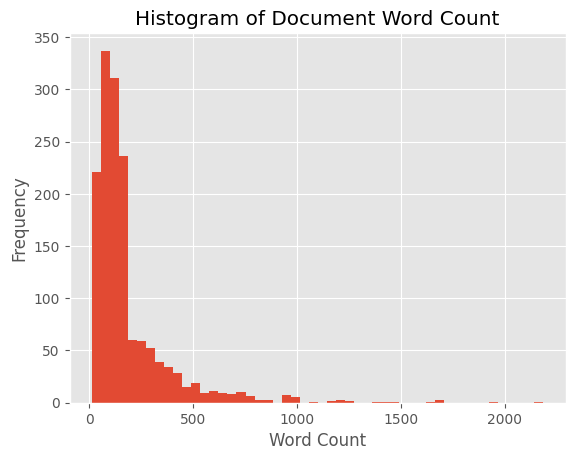

In [6]:
fig, ax = plt.subplots()

df_corpus["word_count"].hist(bins=50, ax=ax)
ax.set_title("Histogram of Document Word Count")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")

plt.show()

## Triplet

In [ ]:
df_triplet = pd.read_json("../data/triplet/triplet.jsonl", lines=True)
print(df_triplet.shape)

df_triplet.head()

(7492, 3)


,query,positive,negative
0,Kumaha cara ngahontal kahayang dina kahirupan?,"Kahiji, urang kedah sabar sareng henteu janten...",Abdi ngadangu seueur warta ngeunaan jalma anu ...
1,Naon anu kedah dilakukeun lamun gering?,"Lamun gering, ulah rungsing sabab pikiran posi...",Masyarakat ayeuna seueur nganggur di kota nu g...
2,Kumaha cara nyieun amal?,"Ngawitan amal ti hal-hal leutik, sapertos ngab...",Jalma sering nyarita ngeunaan kaékonomian anu ...
3,Kumaha sangkan ngeterkeun diri ka Gusti?,"Mertahankeun ati, pariksa tindakan sorangan, s...","Saurang guru ngajarkeun pentingna ilmu, tapi k..."
4,Naon hartina jadi jalma leutik?,Jadi jalma leutik hartina ulah sombong sareng ...,"Dina pagelaran, anu katinggali gaduh prestasi ..."


In [ ]:
df_triplet["query_chars"] = df_triplet["query"].str.len()
df_triplet["positive_chars"] = df_triplet["positive"].str.len()
df_triplet["negative_chars"] = df_triplet["negative"].str.len()

df_triplet.describe()

,query_words,positive_words,negative_words
count,7492.000000,7492.000000,7492.000000
mean,39.810865,101.096369,90.425120
std,9.726668,35.946716,30.653648
min,10.000000,17.000000,13.000000
25%,33.000000,76.000000,69.000000
50%,39.000000,98.000000,88.000000
75%,46.000000,122.000000,109.000000
max,102.000000,326.000000,247.000000


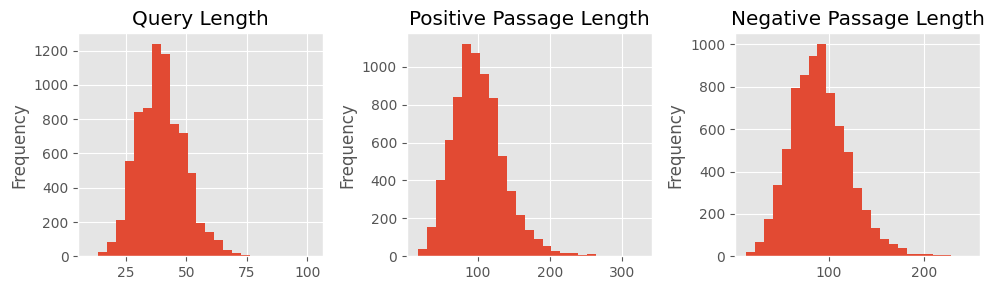

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

df_triplet["query_chars"].plot.hist(bins=25, ax=ax[0])
ax[0].set_title("Query Length")

df_triplet["positive_chars"].plot.hist(bins=25, ax=ax[1])
ax[1].set_title("Positive Passage Length")

df_triplet["negative_chars"].plot.hist(bins=25, ax=ax[2])
ax[2].set_title("Negative Passage Length")

fig.tight_layout()
plt.show()

## BEIR

In [7]:
df_beir_corpus = pd.read_json("../data/beir/corpus.jsonl", lines=True)
print(df_beir_corpus.shape)

df_beir_corpus.head()

(1499, 3)


,_id,title,text
0,0f438470-de7f-47cb-8ba2-16e8b1ff5750,JEMBAR SABAR,bismillah yuga lampah balukar janglar meunang ...
1,c51ddd60-adc7-4b95-b09d-3c4865ba2aaf,KANYERI,eweuh deui seri nu lewih nyeri tibatan di héna...
2,cb4eb9c6-bf7f-4edc-b997-73a02780e60d,KARUNGING LAIN WAYAH,wanci gayuh ka peuting poék tungkeb haté lain ...
3,af9fc2c2-0230-4784-8104-cf9271ccfccc,KUDU DAÉK GAWÉ,ieu awak asa lalungsé di rasa asa carapé meure...
4,2ae6c860-37c6-47f0-aefc-8b74f96b623b,PUISI PANGGGEUING DIRI,naha anjeun téh poho yén mot téh dodoho datang...


In [8]:
df_beir_queries = pd.read_json("../data/beir/queries.jsonl", lines=True)
print(df_beir_queries.shape)

df_beir_queries.head()

(7491, 2)


,_id,text
0,f4ee6408-7047-498e-a319-9189cf81d378,apa maksud dari bismillah yuga lampah
1,c827cfdb-2c57-486f-abc7-80355b884699,kenapa penting sabar dalam hidup
2,0dce18d7-b0b8-4202-a1d5-683489ac423d,apa yang dimaksud dengan halangan dalam mencap...
3,5c961ec5-158a-4073-b33e-3a0be48de7a0,bagaimana cara menjadi orang yang baik menurut...
4,3a019977-ed9b-4d71-8dbd-a65c1c95cc65,apa arti dari pariksa ati


In [23]:
df_beir_queries["text"].str.len().describe()

count    7491.000000
mean       36.721799
std        10.121243
min         8.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        91.000000
Name: text, dtype: float64

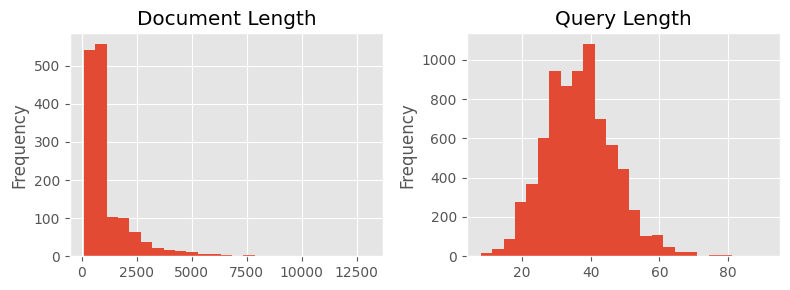

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

df_beir_corpus["text"].str.len().plot.hist(bins=25, ax=ax[0])
ax[0].set_title("Document Length")

df_beir_queries["text"].str.len().plot.hist(bins=25, ax=ax[1])
ax[1].set_title("Query Length")

fig.tight_layout()
plt.show()

In [10]:
df_beir_qrels = pd.read_csv("../data/beir/qrels.tsv", sep="\t")
print(df_beir_qrels.shape)

df_beir_qrels.head()

(7491, 3)


,query-id,corpus-id,score
0,f4ee6408-7047-498e-a319-9189cf81d378,0f438470-de7f-47cb-8ba2-16e8b1ff5750,1
1,c827cfdb-2c57-486f-abc7-80355b884699,0f438470-de7f-47cb-8ba2-16e8b1ff5750,1
2,0dce18d7-b0b8-4202-a1d5-683489ac423d,0f438470-de7f-47cb-8ba2-16e8b1ff5750,1
3,5c961ec5-158a-4073-b33e-3a0be48de7a0,0f438470-de7f-47cb-8ba2-16e8b1ff5750,1
4,3a019977-ed9b-4d71-8dbd-a65c1c95cc65,0f438470-de7f-47cb-8ba2-16e8b1ff5750,1


### Frequency Distribution

In [11]:
tokenizer = nltk.WhitespaceTokenizer()
tokens = [
    tokenizer.tokenize(s.lower())
    for s in df_beir_corpus["text"]
]

freq = nltk.FreqDist(itertools.chain(*tokens))
freq

FreqDist({'nu': 7307, 'ka': 3730, 'anu': 3464, 'di': 3430, 'jeung': 3282, 'ku': 3266, 'teu': 2660, 'dina': 2609, 'aya': 2099, 'atawa': 1820, ...})

In [12]:
freq_common = freq.most_common(20)
df_common = pd.Series([x[1] for x in freq_common], index=[x[0] for x in freq_common])
df_common

nu       7307
ka       3730
anu      3464
di       3430
jeung    3282
ku       3266
teu      2660
dina     2609
aya      2099
atawa    1820
ti       1685
téh      1579
geus     1461
tina     1371
jadi     1363
urang    1339
mah      1269
bisa     1114
kana     1059
keur      942
dtype: int64

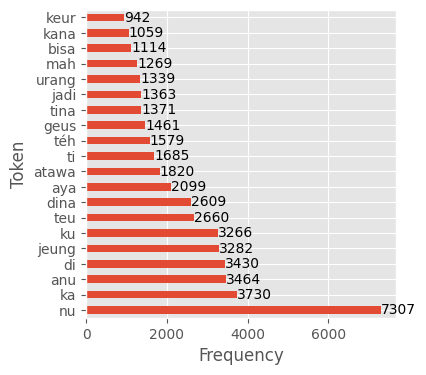

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))

df_common.plot.barh(ax=ax)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Frequency")
ax.set_ylabel("Token")

plt.show()